# Chuẩn bị Data

## Tải data từ kaggle xuống và giải nén


In [1]:
!pip install kaggle
!kaggle datasets download -d msambare/fer2013
!unzip fer2013.zip
!rm fer2013.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

# Trực quan hóa dữ liệu

## Số ảnh trong tập train và test trên từng nhãn

In [2]:
import os

def count_images_per_subdir(root_dir):
  """Counts the number of images in each subdirectory of a given directory.

  Args:
    root_dir: The path to the root directory.

  Returns:
    A dictionary where keys are subdirectory names and values are the number of images in each subdirectory.
  """

  image_counts = {}
  for subdir, _, files in os.walk(root_dir):
    image_count = 0
    for file in files:
      if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_count += 1
    if image_count > 0:  # Only include subdirectories with images.
      subdir_name = os.path.basename(subdir)
      image_counts[subdir_name] = image_count
  return image_counts


# Example usage:
train_dir = '/content/train'
test_dir = '/content/test'

train_image_counts = count_images_per_subdir(train_dir)
test_image_counts = count_images_per_subdir(test_dir)

print("Number of images in each subdirectory of 'train':")
for subdir, count in train_image_counts.items():
  print(f"{subdir}: {count}")

print("\nNumber of images in each subdirectory of 'test':")
for subdir, count in test_image_counts.items():
  print(f"{subdir}: {count}")


Number of images in each subdirectory of 'train':
neutral: 4965
fear: 4097
happy: 7215
disgust: 436
sad: 4830
surprise: 3171
angry: 3995

Number of images in each subdirectory of 'test':
neutral: 1233
fear: 1024
happy: 1774
disgust: 111
sad: 1247
surprise: 831
angry: 958


## Vẽ biểu đồ


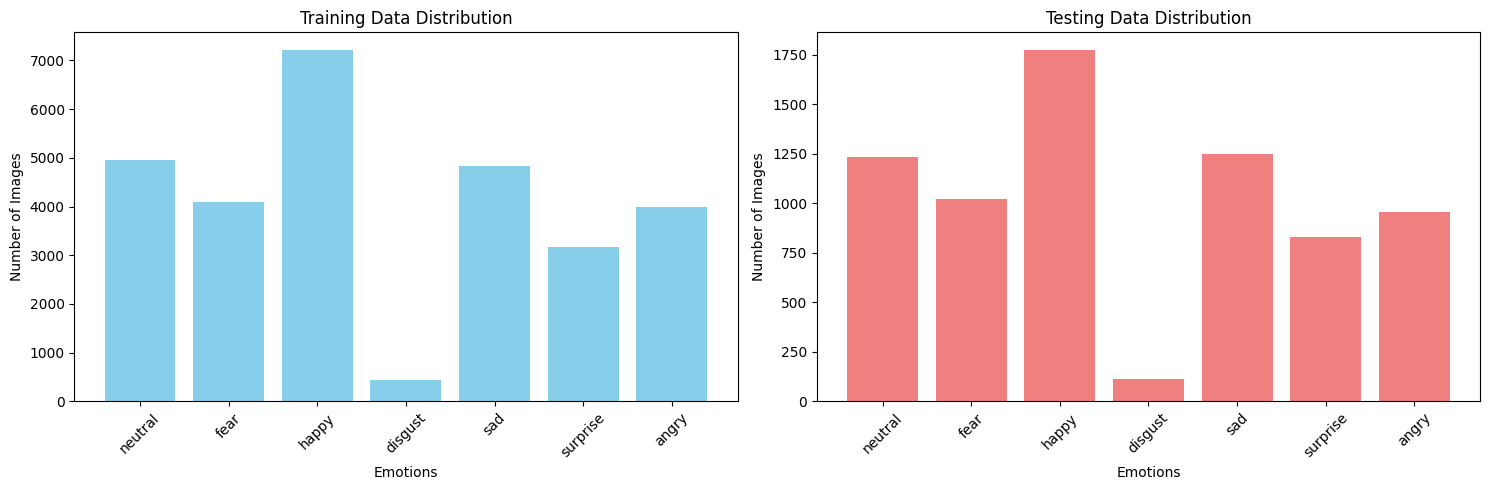

In [3]:
import matplotlib.pyplot as plt

# Prepare data for plotting
emotions_train = list(train_image_counts.keys())
counts_train = list(train_image_counts.values())

emotions_test = list(test_image_counts.keys())
counts_test = list(test_image_counts.values())

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot histogram for training data
axes[0].bar(emotions_train, counts_train, color='skyblue')
axes[0].set_title('Training Data Distribution')
axes[0].set_xlabel('Emotions')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability


# Plot histogram for testing data
axes[1].bar(emotions_test, counts_test, color='lightcoral')
axes[1].set_title('Testing Data Distribution')
axes[1].set_xlabel('Emotions')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45) # Rotate x-axis labels


plt.tight_layout()
plt.show()


Nhận xét: Nhãn disgust ít hơn hẳn so với các nhãn khác.

Có thể xem xét bỏ cột này để mô hình học tốt hơn


# Tiền xử lý dữ liệu

## Loại bỏ nhãn disgust

In [4]:
import os
import shutil

def remove_disgust_label(root_dir):
    """Removes the 'disgust' subdirectory and its contents from the given root directory.

    Args:
        root_dir: The path to the root directory containing the subdirectories for each emotion label.
    """

    disgust_dir = os.path.join(root_dir, 'disgust')
    if os.path.exists(disgust_dir):
        shutil.rmtree(disgust_dir)
        print(f"Removed 'disgust' directory from {root_dir}")
    else:
        print(f"'disgust' directory not found in {root_dir}")

# Example usage
train_dir = '/content/train'
test_dir = '/content/test'

remove_disgust_label(train_dir)
remove_disgust_label(test_dir)


Removed 'disgust' directory from /content/train
Removed 'disgust' directory from /content/test


#Huấn luyên mô hình

In [5]:
from torch.utils.data import DataLoader, TensorDataset
from torch.nn import Module, Conv2d, Linear, MaxPool2d, ReLU, Dropout, BatchNorm2d , Flatten, Softmax
from torch.optim import Adam
from torchsummary import summary
import torch.nn as nn

In [6]:
class CNN(nn.Module):
    def __init__(self, channels, num_classes):
        super().__init__()

        # Convolutional layers
        self.conv1 = Conv2d(in_channels=channels, out_channels=32, kernel_size=(5, 5), padding=2)
        self.conv2 = Conv2d(in_channels=32, out_channels=64, kernel_size=(5, 5), padding=2)
        self.conv3 = Conv2d(in_channels=64, out_channels=128, kernel_size=(5, 5), padding=2)
        self.conv4 = Conv2d(in_channels=128, out_channels=512, kernel_size=(5, 5), padding=2)
        self.conv5 = Conv2d(in_channels=512, out_channels=1024, kernel_size=(3, 3), padding=1)

        # Batch normalization
        self.batchnorm1 = BatchNorm2d(num_features=32)
        self.batchnorm2 = BatchNorm2d(num_features=64)
        self.batchnorm3 = BatchNorm2d(num_features=128)
        self.batchnorm4 = BatchNorm2d(num_features=512)
        self.batchnorm5 = BatchNorm2d(num_features=1024)

        # Other layers
        self.maxpool = MaxPool2d(kernel_size=(2, 2))
        self.relu = ReLU()
        self.dropout = Dropout(p=0.2)

        # Fully connected layers
        self.flatten = Flatten()
        self.fc1 = Linear(in_features=1024, out_features=512)
        self.fc2 = Linear(in_features=512, out_features=128)
        self.fc3 = Linear(in_features=128, out_features=num_classes)
        self.softmax = Softmax(dim=1)



    def forward(self, X):
        # block 1
        X = self.conv1(X)
        X = self.batchnorm1(X)
        X = self.relu(X)
        X = self.maxpool(X)

        # block 2
        X = self.conv2(X)
        X = self.batchnorm2(X)
        X = self.relu(X)
        X = self.maxpool(X)

        # block 3
        X = self.conv3(X)
        X = self.batchnorm3(X)
        X = self.relu(X)
        X = self.maxpool(X)

        # block 4
        X = self.conv4(X)
        X = self.batchnorm4(X)
        X = self.relu(X)
        X = self.maxpool(X)
        X = self.dropout(X)

        # block 5
        X = self.conv5(X)
        X = self.batchnorm5(X)
        X = self.relu(X)
        X = self.maxpool(X)
        X = self.dropout(X)


        # fully connected layer
        X = self.flatten(X)
        X = self.fc1(X)
        X = self.relu(X)
        X = self.dropout(X)

        X = self.fc2(X)
        X = self.relu(X)
        X = self.dropout(X)

        X = self.fc3(X)
        return X
model = CNN(channels = 3, num_classes = 6)

Epoch: 50/50, Loss: 0.236030146, Time/epoch: 23.16s


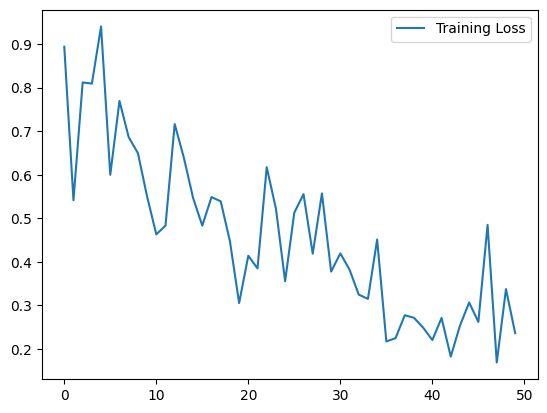

Total runtime: 1150.89s


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
import timeit
from IPython.display import clear_output

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Thông số huấn luyện
img_width, img_height = 48, 48
batch_size = 64
epochs = 50
learning_rate = 0.0001

# Xử lý ảnh
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Chuyển grayscale thành 3 kênh
    transforms.Resize((img_width, img_height)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=10, shear=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Chuẩn hóa
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((img_width, img_height)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load dữ liệu
train_dataset = datasets.ImageFolder(root='/content/train', transform=transform_train)
test_dataset = datasets.ImageFolder(root='/content/test', transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.to(device)

# Hàm mất mát & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
output_loss = []
start = timeit.default_timer()

for epoch in range(epochs):
    epoch_start = timeit.default_timer()
    model.train()

    for batch in train_loader:
        x, y = batch[0].to(device), batch[1].to(device)

        # Forward
        y_pred = model(x)
        loss = criterion(y_pred, y)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    output_loss.append(loss.item())
    epoch_end = timeit.default_timer()

    # Hiển thị tiến trình
    clear_output(wait=True)
    print(f'Epoch: {epoch+1}/{epochs}, Loss: {loss.item():.9f}, Time/epoch: {epoch_end - epoch_start:.2f}s')

    plt.plot(output_loss, label='Training Loss')
    plt.legend()
    plt.show()

end = timeit.default_timer()
print(f'Total runtime: {end - start:.2f}s')


In [11]:
model.eval()  # Đặt model vào chế độ đánh giá
correct = 0
total = 0
with torch.no_grad():  # Không tính toán gradient trong quá trình đánh giá
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the model on the test images: {accuracy:.2f}%')


Accuracy of the model on the test images: 64.53%


In [12]:
# prompt: classification report

from sklearn.metrics import classification_report

# ... (your existing code) ...

# Evaluation (after training loop)
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=train_dataset.classes))


              precision    recall  f1-score   support

       angry       0.67      0.48      0.56       958
        fear       0.46      0.55      0.50      1024
       happy       0.82      0.84      0.83      1774
     neutral       0.57      0.63      0.60      1233
         sad       0.52      0.48      0.50      1247
    surprise       0.82      0.78      0.80       831

    accuracy                           0.65      7067
   macro avg       0.64      0.63      0.63      7067
weighted avg       0.65      0.65      0.65      7067



In [13]:
torch.save(model.state_dict(), 'emotion_recognition_model.pth')